In [1]:
import pypdf

Número de PDFs:

In [2]:
import os

path_to_data = "./data"

total_pdfs = len([f for f in os.listdir(path_to_data) if f.endswith('.pdf')])
print(f"Total PDFs found: {total_pdfs}")

Total PDFs found: 42


Total pages across all PDFs 3781
PDFs with more than 100 pages:
BOE-A-2004-18911-consolidado.pdf: 375 pages
Manual_IVA_2025.pdf: 350 pages
BOE-A-1889-4763-consolidado.pdf: 282 pages
BOE-A-2015-11724-consolidado.pdf: 272 pages
BOE-015_Codigo_de_Propiedad_Horizontal.pdf: 263 pages
ANM2026_197.pdf: 241 pages
estatuto_de_los_trabajadores.pdf: 232 pages
BOE-A-1995-25444-consolidado.pdf: 207 pages
BOE-A-2015-7391-consolidado.pdf: 131 pages
BOE-A-1030-2006-consolidado.pdf: 104 pages
BOE-A-2007-20555-consolidado.pdf: 103 pages
CELEX_32022R2065_ES_TXT.pdf: 102 pages


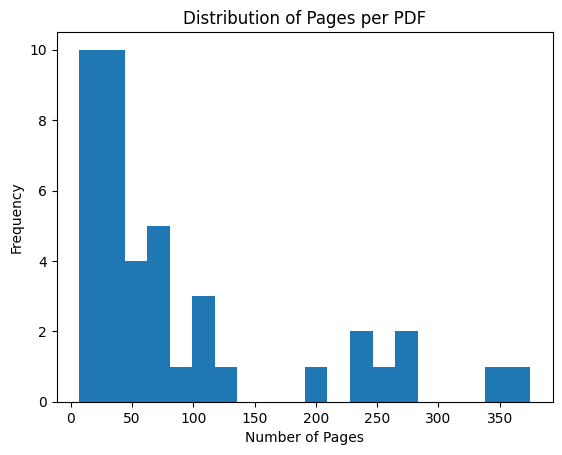

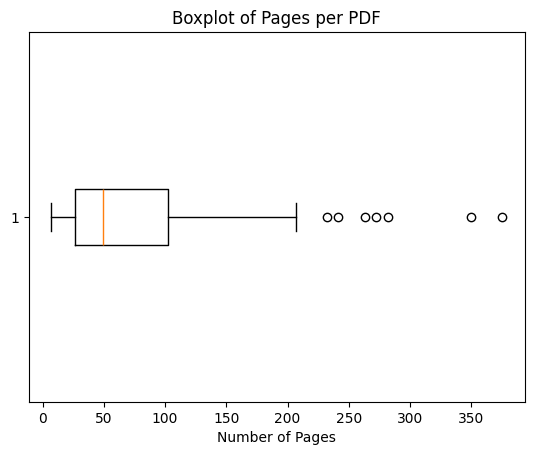

Mean: 90.02380952380952
Median: 49.0
Standard Deviation: 98.2076245937385
Min: 7
Max: 375


In [3]:
import matplotlib.pyplot as plt

# distribution of pages per PDF
pages_per_pdf = {}
for filename in os.listdir(path_to_data):
    if filename.endswith('.pdf'):
        pdf_path = os.path.join(path_to_data, filename)
        try:
            with open(pdf_path, 'rb') as f:
                reader = pypdf.PdfReader(f)
                pages_per_pdf[filename] = len(reader.pages)
        except Exception as e:
            print(f"Error reading {filename}: {e}")

print("Total pages across all PDFs", sum(pages_per_pdf.values()))

# PDFs with more than 100 pages ordered by number of pages
long_pdfs = {k: v for k, v in pages_per_pdf.items() if v > 100}
long_pdfs = dict(sorted(long_pdfs.items(), key=lambda item: item[1], reverse=True))
print("PDFs with more than 100 pages:")
for filename, num_pages in long_pdfs.items():
    print(f"{filename}: {num_pages} pages")

# plot distribution
plt.hist(pages_per_pdf.values(), bins=20)
plt.title('Distribution of Pages per PDF')
plt.xlabel('Number of Pages')
plt.ylabel('Frequency')
plt.show()  

# boxplot
plt.boxplot(pages_per_pdf.values(), vert=False)
plt.title('Boxplot of Pages per PDF')
plt.xlabel('Number of Pages')
plt.show()

# describe statistics
import numpy as np
pages_array = np.array(list(pages_per_pdf.values()))
print(f"Mean: {np.mean(pages_array)}")
print(f"Median: {np.median(pages_array)}")
print(f"Standard Deviation: {np.std(pages_array)}")
print(f"Min: {np.min(pages_array)}")
print(f"Max: {np.max(pages_array)}")

In [ ]:
import pdfplumber
import pandas as pd

tablas_pdf = {}
num_tab = 0
#Leer tablas cada documento
for filename in os.listdir(path_to_data):
    if filename.endswith('.pdf'):
        pdf_path = os.path.join(path_to_data, filename)
        try:
            with pdfplumber.open(pdf_path) as pdf:
                num_tab = 0
                for page in pdf.pages:
                    table = page.extract_table()
                    if table is not None:
                        num_tab +=1
        except Exception as e:
            print(f"Error reading {filename}: {e}")

    tablas_pdf[filename] = num_tab
    if tablas_pdf[filename] != 0:
        print(" El documento ", filename, "SI contiene tablas.")

# Distribución de documentos con tablas
plt.hist(tablas_pdf.values(), bins=20)
plt.title('Distribution of Tables per PDF')
plt.xlabel('Number of Tables')
plt.ylabel('Frequency')
plt.show()

# Estadísticas de documentos con tablas
table_array = np.array(list(tablas_pdf.values()))
print(f"Mean: {np.mean(table_array)}")
print(f"Median: {np.median(table_array)}")
print(f"Standard Deviation: {np.std(table_array)}")
print(f"Min: {np.min(table_array)}")
print(f"Max: {np.max(table_array)}")

In [ ]:
# Cantidad de palabras por por página y pdf
for filename in os.listdir(path_to_data):
    if filename.endswith('.pdf'):
        pdf_path = os.path.join(path_to_data, filename)
        try:
            with open(pdf_path, 'rb') as f:
                reader = pypdf.PdfReader(f)
                words_pdf = {}
                npage = 0
                for page in reader.pages:
                    text = page.extract_text()
                    words = text.split()
                    num_words = len(words)
                    words_pdf[npage] = num_words
                    npage += 1
            
            plt.plot(words_pdf.values())
            plt.title('Number of Words for PDF')
            plt.xlabel('Number of Page')
            plt.ylabel('Number of Words')
            plt.show()
            # Distribución de palabras por pdf
            plt.hist(words_pdf.values())
            plt.title('Distribution of Words for PDF')
            plt.xlabel('Number of Words')
            plt.ylabel('Frequency')
            plt.show()

            # Estadísticas
            words_array = np.array(list(words_pdf.values()))
            print(f"Mean: {np.mean(words_array)}")
            print(f"Median: {np.median(words_array)}")
            print(f"Standard Deviation: {np.std(words_array)}")
            print(f"Min: {np.min(words_array)}")
            print(f"Max: {np.max(words_array)}")
        except Exception as e:
            print(f"Error reading {filename}: {e}")

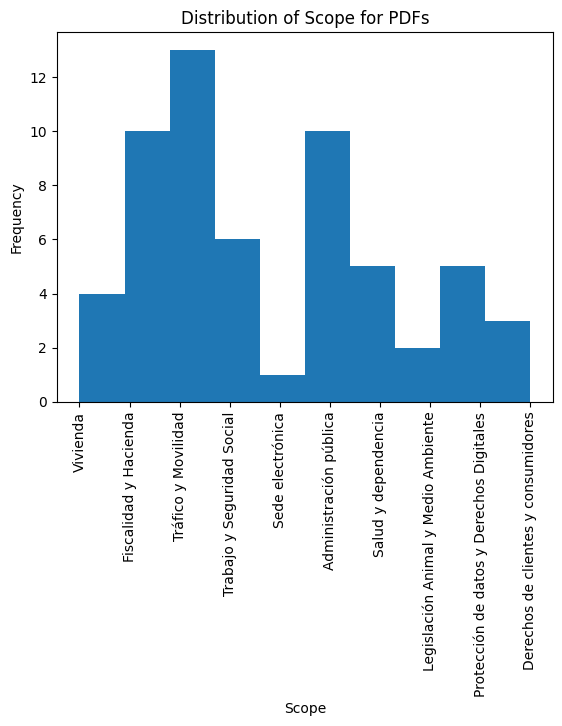

In [26]:
# Distribución tipo documento
data_hard = pd.read_csv("dataset_eda.csv")
data_soft = data_hard.filter(items=["Nombre del archivo", "Área"])

# Distribución de ámbitos
plt.hist(data_soft["Área"])
plt.title('Distribution of Scope for PDFs')
plt.xlabel('Scope')
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.show()

Error reading Manual_IVA_2025.pdf: cryptography>=3.1 is required for AES algorithm
Total images across all PDFs 6672
PDFs with more than 10 images:
ANM2026_197.pdf: 6266 images
BOE-A-2023-7936.pdf: 108 images
BOE-A-2022-987.pdf: 68 images
BOE-A-2004-18911-consolidado.pdf: 65 images
guia_firma_electronica.pdf: 35 images
BOE-015_Codigo_de_Propiedad_Horizontal.pdf: 29 images
BOE-A-2024-2248.pdf: 26 images
guia-cookies.pdf: 20 images


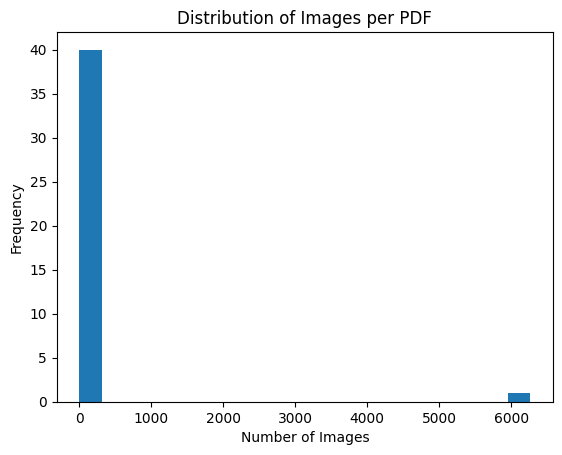

Mean: 162.73170731707316
Median: 1.0
Standard Deviation: 965.2613199667303
Min: 0
Max: 6266


In [ ]:
# images in PDFs
images_per_pdf = {}
for filename in os.listdir(path_to_data):
    if filename.endswith('.pdf'):
        pdf_path = os.path.join(path_to_data, filename)
        try:
            with open(pdf_path, 'rb') as f:
                reader = pypdf.PdfReader(f)
                num_images = 0
                for page in reader.pages:
                    if '/XObject' in page['/Resources']:
                        xobjects = page['/Resources']['/XObject'].get_object()
                        for obj in xobjects:
                            if xobjects[obj]['/Subtype'] == '/Image':
                                num_images += 1
                images_per_pdf[filename] = num_images
        except Exception as e:
            print(f"Error reading {filename}: {e}")

print("Total images across all PDFs", sum(images_per_pdf.values()))

# PDFs with more than 10 images ordered by number of images
image_rich_pdfs = {k: v for k, v in images_per_pdf.items() if v > 10}
image_rich_pdfs = dict(sorted(image_rich_pdfs.items(), key=lambda item: item[1], reverse=True))
print("PDFs with more than 10 images:")
for filename, num_images in image_rich_pdfs.items():
    print(f"{filename}: {num_images} images")

# plot distribution of images
plt.hist(images_per_pdf.values(), bins=20)
plt.title('Distribution of Images per PDF')
plt.xlabel('Number of Images')
plt.ylabel('Frequency')
plt.show()

# describe statistics of images
images_array = np.array(list(images_per_pdf.values()))
print(f"Mean: {np.mean(images_array)}")
print(f"Median: {np.median(images_array)}")
print(f"Standard Deviation: {np.std(images_array)}")
print(f"Min: {np.min(images_array)}")
print(f"Max: {np.max(images_array)}")